In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from copy import deepcopy
import datetime
from astropy import units as u
from astropy import constants as const
from astroquery.mast import Catalogs
import lightkurve as lk
from dace_query.spectroscopy import Spectroscopy
from scipy import optimize
import batman
import radvel
from radvel.plot import orbit_plots

2026-09-08 23:00:15,481 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [2]:
render_plots = True

In [3]:
input_catalog = input('input catalog: ').upper()
split = input_catalog.split(' ')
telescope = split[0]
if telescope == 'TIC':
    author = 'SPOC'
if telescope == 'KIC':
    author = 'Kepler'

nasa_archive_filepath = '/Users/joshu/Code/NasaExoplanetArchive_2026.08.23_12.42.57.csv' 
nasa_archive = pd.read_csv(nasa_archive_filepath, comment = '#')
nasa_exo = nasa_archive[nasa_archive['tic_id'] == input_catalog]
print(f'Parent Star: {nasa_exo.iloc[0]['hostname']}')
print(f'Distance: {np.round(nasa_exo.iloc[0]['sy_dist']*u.parsec.to(u.lightyear), 2)} ly')

try:
    star = Catalogs.query_object(input_catalog, catalog = 'TIC') 
    star_Teff = star['Teff'][0]
    star_lumclass = str(star['lumclass'][0]).capitalize()
    if star_Teff >= 33000:
        stellar_class = str(f'O-Type Blue {star_lumclass}')
    elif star_Teff >= 10000:
        stellar_class = str(f'B-Type Blue/White {star_lumclass}')
    elif star_Teff >= 7300:
        stellar_class = str(f'A-Type White {star_lumclass}')
    elif star_Teff >= 6000:
        stellar_class = str(f'F-Type White/Yellow {star_lumclass}')
    elif star_Teff >= 5300:
        stellar_class = str(f'G-Type Yellow {star_lumclass}')
    elif star_Teff >= 3900:
        stellar_class = str(f'K-Type Orange {star_lumclass}')
    elif star_Teff >= 2300:
        stellar_class = str(f'M-Type Red {star_lumclass}')
    else:
        stellar_class = 'Brown Dwarf'  
    print(f'Stellar Class: {stellar_class}')
except:
    print('MAST import error: try again')

RV = False
if nasa_exo['rv_flag'].any() == 1:
    RV = True
print(f'Radial Velocity Available: {RV}')

input catalog:  TIC 238176110


Parent Star: WASP-91
Distance: 489.05 ly
Stellar Class: K-Type Orange Dwarf
Radial Velocity Available: True


### Transit Method

In [4]:
automate_data_cell = True

In [5]:
def import_tess(input_catalog, author, all_data, years):    
    sectors_list = []
    for sector in all_data.table:
        sectors_list.append(int(sector['sequence_number']))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:           
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        
    print('\nselected data:')
    print(selected_data)        
    return raw_ts, sectors_list, selected_data

def import_kepler(input_catalog, author, all_data, years):    
    quarters_list = []
    for quarter in all_data.table:
        quarters_list.append(int(quarter['mission'].split(' ')[2]))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:            
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()

        
    print('\nselected data:')
    print(selected_data)
    return raw_ts, quarters_list, selected_data

def limit_range(all_data):
    all_years = []
    for each in all_data:
        all_years.append(each.year.item())
    yr_max_i = np.max(range(len(all_years)))
    yr_max = (all_years[yr_max_i])
    yr_min = (all_years[0])
    yr_range = yr_max - yr_min

    if yr_range > 5:
        yr_count = np.bincount(all_years)
        yr_mode = round(np.argmax(yr_count))
        yr_median = round(np.median(all_years))

        if np.max(yr_count) > 5:
            year_mask = (all_data.table['year'] >= yr_mode - 2) & (all_data.table['year'] <= yr_mode + 2)
        else:
            year_mask = (all_data.table['year'] >= yr_median - 2) & (all_data.table['year'] <= yr_median + 2)
    else:
        year_mask = all_years
    return yr_range, year_mask

all_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short')
print('all data:')
print(all_data)

if automate_data_cell == True:
    years = 0
    automate_data_cell = False
else:
    years_input = input('Year Range: ')
    years_range = years_input.split('-')
    years_min = int(years_range[0])
    years_max = int(years_range[-1])
    if years_min != years_max:
        years = [years_min]
        i = 1
        while years[-1] != years_max:
            years.append(years_min + i)
            i += 1
    
if telescope == 'TIC':
    raw_ts, sectors, selected_data = import_tess(input_catalog, author, all_data, years)
if telescope == 'KIC':
    raw_ts, quarters, selected_data = import_kepler(input_catalog, author, all_data, years)

all data:
SearchResult containing 10 data products.

 #      mission     year author exptime target_name distance
                                   s                 arcsec 
--- --------------- ---- ------ ------- ----------- --------
  0  TESS Sector 01 2018   SPOC     120   238176110      0.0
  1  TESS Sector 27 2020   SPOC     120   238176110      0.0
  2  TESS Sector 28 2020   SPOC     120   238176110      0.0
  3  TESS Sector 67 2023   SPOC     120   238176110      0.0
  4  TESS Sector 68 2023   SPOC     120   238176110      0.0
  5  TESS Sector 94 2025   SPOC     120   238176110      0.0
  6  TESS Sector 95 2025   SPOC     120   238176110      0.0
  7 TESS Sector 102 2026   SPOC     120   238176110      0.0
  8 TESS Sector 103 2026   SPOC     120   238176110      0.0
  9 TESS Sector 104 2026   SPOC     120   238176110      0.0

selected data:
SearchResult containing 7 data products.

 #      mission     year author exptime target_name distance
                                   

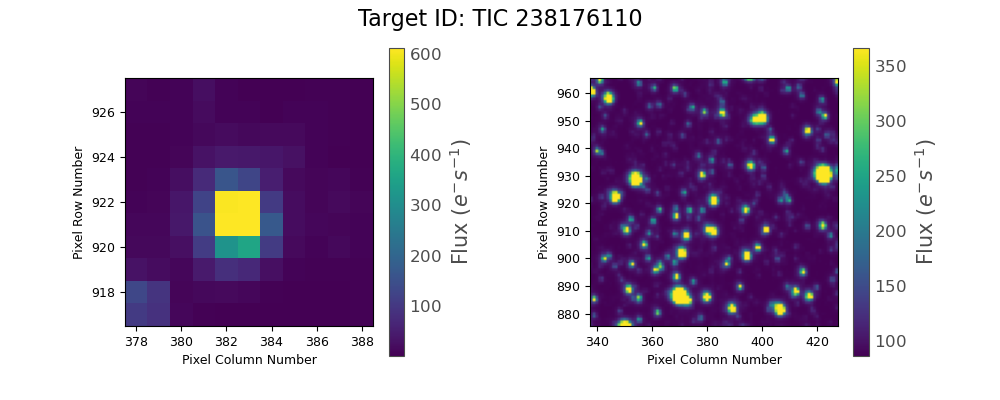

In [6]:
if render_plots == True:
    if telescope == 'TIC':
        fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))
        fig.suptitle(f'Target ID: {input_catalog}', fontsize = 16)
        fig.subplots_adjust(wspace = .5)
        
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', sector = sectors[0]).download()
        px_file.plot(ax = ax1, title = '')
        
        ff_file = lk.search_tesscut(input_catalog, sector = sectors[0]).download(cutout_size = 90)
        ff_file.plot(ax = ax2, title = '')
        
    if telescope == 'KIC':
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', quarter = quarters[0]).download()
        px_file.plot()
        plt.title(f'Target ID: {input_catalog}', fontsize = 16)

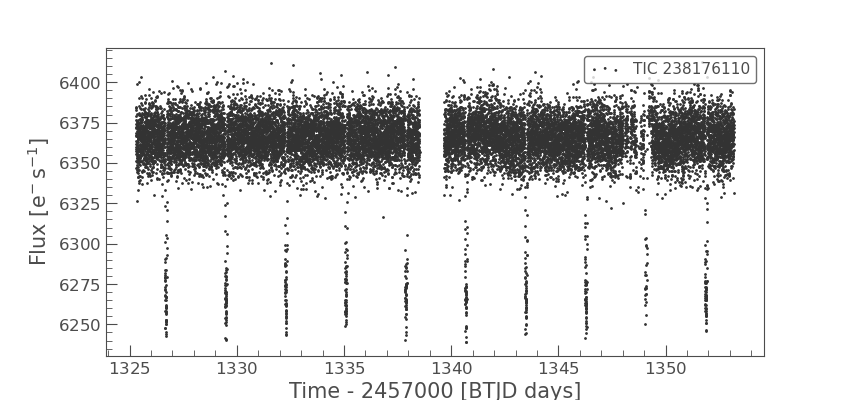

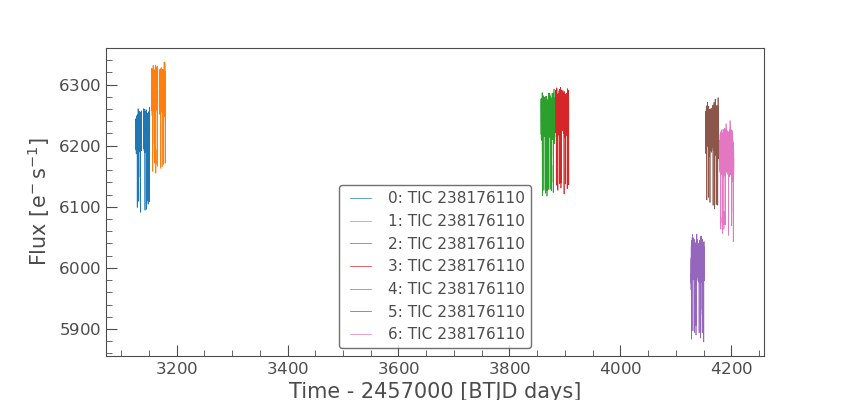

In [7]:
if telescope == 'TIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors[0], limit = 1).download()
    if len(sectors) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if telescope == 'KIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters[0], limit = 1).download()
    if len(quarters) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if render_plots == True:
    first_ts.scatter()
    raw_ts.plot()

In [8]:
bin_count = 100000
if len(refined_ts) > bin_count:
    bin_width = (np.max(refined_ts.time.value)-np.min(refined_ts.time.value))/(bin_count/.94)
    harmonics_ts = refined_ts.bin(bin_width) 
else:
    harmonics_ts = refined_ts
print(f'Count of points in harmonics test: {len(harmonics_ts)}')

Count of points in harmonics test: 106383


In [9]:
add_period = False

`period` contains 172100 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Exoplanet Index: 0
Period: 2.7986 d (SNR: 356.5351)



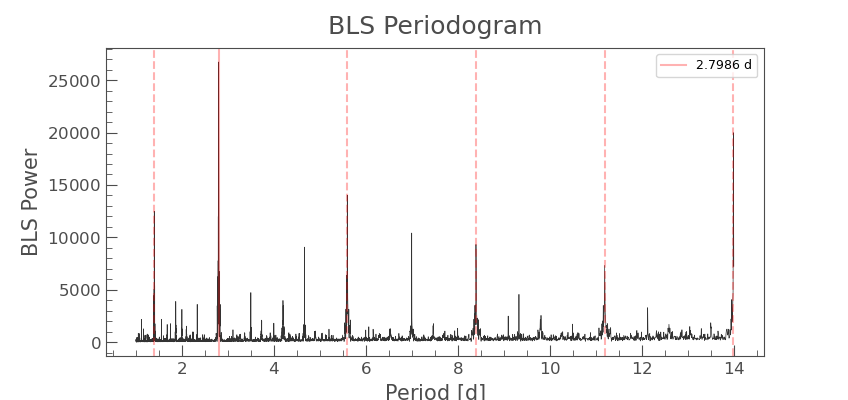

In [10]:
def initial_bls(ts, min_period, max_period):
    search_duration = np.linspace(.05, .3, 10)
    search_period = np.logspace(np.log10(min_period), np.log10(max_period), 5000) 
    initial_periodogram = ts.to_periodogram(method = 'bls', period = search_period, duration = search_duration, frequency_factor = 1000)
    initial_period = initial_periodogram.period_at_max_power
    initial_duration = initial_periodogram.duration_at_max_power  
    return initial_periodogram, initial_period, initial_duration
    
def refine_bls(ts, prev_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(prev_period.value - .1, prev_period.value + .1, 5000)
    refined_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    refined_period = refined_periodogram.period_at_max_power
    refined_duration = refined_periodogram.duration_at_max_power
    refined_time = refined_periodogram.transit_time_at_max_power
    refined_depth = refined_periodogram.depth_at_max_power
    return refined_periodogram, refined_period, refined_duration, refined_time, refined_depth

def search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts):
    harmonics = [refined_period.value]
    i = 2
    while i <= 5:
        harmonics_divide = refined_period.value/i
        harmonics_multiply = refined_period.value*i
        if harmonics_divide >= min_period:
            harmonics.append(harmonics_divide)
        if harmonics_multiply <= max_period:
            harmonics.append(harmonics_multiply)
        i += 1 
    harmonics.sort()
    
    dip_ratio = []
    for each in harmonics:
        folded = harmonics_ts.fold(period = each, epoch_time = refined_time)
        in_transit = np.logical_and((folded.phase.value > -refined_duration.value/3), (folded.phase.value < refined_duration.value/3))
        above_dip = folded.flux.value > 1-refined_depth*(2/3)
        both = np.logical_and(in_transit, above_dip)
        dip_ratio.append(len(folded[both])/len(folded[in_transit]))

        #lim_folded = folded[in_transit]
        #folded.scatter(title = f'index {harmonics.index(each)}: {round(each*u.day,4)}')
        #plt.axhline(1-refined_periodogram.depth_at_max_power*(2/3), color = "green")
        #plt.axvline(-refined_duration.value/3, color = "green")
        #plt.axvline(refined_duration.value/3, color = "green")
        #plt.xlim(-.1,.1)
        #plt.ylim(.9995, 1.0005)
    
    high_freq_h = []
    mean = (dip_ratio[0]+dip_ratio[-1])/2
    
    i = 0
    while i < len(dip_ratio):
        if dip_ratio[i] > mean:
            high_freq_h.append(dip_ratio[i])
        i += 1
    
    transit_index = len(high_freq_h)
    return harmonics, transit_index

def mask_ts(time_series, ts, selected_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(selected_period - .1, selected_period + .1, 5000)
    final_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    final_period = final_periodogram.period_at_max_power
    final_duration = final_periodogram.duration_at_max_power
    final_time = final_periodogram.transit_time_at_max_power
    final_depth = final_periodogram.depth_at_max_power
    
    mask = final_periodogram.get_transit_mask(period = final_period, transit_time = final_time, duration = final_duration*2)
    masked_ts = ts[~mask]
    time_series.append(masked_ts)
    return final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth

def plot_periodogram(periodogram, selected_periods, min_period, max_period):
    periodogram.plot(title = 'BLS Periodogram', label = '_nolegend_')
    
    i = 0
    while i < len(selected_periods):
        if i == 0:
            color = 'red'
        if i == 1:
            color = 'green'
        if i == 2:
            color = 'blue'
        if i == 3:
            color = 'orange'
        if i == 4:
            color = 'purple'
        plt.axvline(selected_periods[i], color = color, alpha = .3)

        labels = []
        for each in selected_periods:
            labels.append(round(each,4)*u.day)
        plt.legend(labels)
        
        x = 2
        while x <= 5:
            harmonics_divide = selected_periods[i]/x
            harmonics_multiply = selected_periods[i]*x
            if harmonics_divide >= min_period:
                plt.axvline(harmonics_divide, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            if harmonics_multiply <= max_period:
                plt.axvline(harmonics_multiply, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            x += 1 
        i += 1

if add_period == False:
    min_period = 1
    max_period = 14
    time_series = [refined_ts]
    cycle = 0
    selected_periods = []
    exoplanets = []
    periods = []
    durations = []
    transit_times = []
    
    while True:
        initial_periodogram, initial_period, initial_duration = initial_bls(time_series[-1], min_period, max_period)
        if cycle == 0:
            first_periodogram = initial_periodogram
        cycle += 1
    
        refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
        if np.max(refined_periodogram.snr) < 10:
            break

        harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
        for each in harmonics:
            if each == harmonics[transit_index]:
                selected_periods.append(each)
        
        final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
        exoplanets.append({
            'catalog': input_catalog,
            'stellar_class': stellar_class,
            'period': final_period, 
            'duration': final_duration, 
            'transit_t0': final_time,       
            'depth': final_depth,
            'snr': np.max(final_periodogram.snr)
        }) 
        periods.append(final_period.value)
        durations.append(final_duration.value)
        transit_times.append(final_time.value)
    add_period = True
else:
    refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
    harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
    for each in harmonics:
        if each == harmonics[transit_index]:
            selected_periods.append(each)
    final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
    exoplanets.append({
        'catalog': input_catalog,
        'stellar_class': stellar_class,
        'period': final_period, 
        'duration': final_duration, 
        'transit_t0': final_time,       
        'depth': final_depth,
        'snr': np.max(final_periodogram.snr)
    }) 
    periods.append(final_period.value)
    durations.append(final_duration.value)
    transit_times.append(final_time.value)  

for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    print(f'Period: {round(each["period"],4)} (SNR: {round(each["snr"],4)})')
    print()
plot_periodogram(first_periodogram, selected_periods, min_period, max_period)

In [11]:
def orbital_distance(star, period):
    star_mass = star['mass'][0]* u.M_sun
    star_mass = star_mass.to(u.kg)
    period = period.to(u.s)
    sm_axis = np.cbrt((const.G*star_mass*np.square(period))/(4*np.square(np.pi)))
    sm_axis = sm_axis.to(u.au)
    print(f'Semimajor Axis: {round(sm_axis, 4)}') 
    return sm_axis

def equ_temperature(star, sm_axis):
    star_rad = star['rad'][0]*u.Rsun.to(u.m)*u.m
    star_temp = star_Teff*u.k
    sm_axis_m = sm_axis.to(u.m)
    equ_temp = star_temp * ((star_rad/(2*sm_axis_m))**(1/2)) * (1**(1/4))
    print(f'Equilibrium Temperature: {round(equ_temp, 4)}')
    return equ_temp

def habitable_zone(star, sm_axis):
    star_luminosity = star['lum'][0]*u.L_sun
    inner_lim = np.sqrt(star_luminosity/(1.1*u.L_sun))*u.au
    outer_lim = np.sqrt(star_luminosity/(.53*u.L_sun))*u.au

    if sm_axis < inner_lim:
        habitability = 'too hot'
    elif sm_axis > outer_lim:
        habitability = 'too cold'
    else:
        habitability = 'just right'
    print(f'Habitability: {habitability}')
    return habitability

for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    sm_axis = orbital_distance(star, each['period'])
    each['sm_axis'] = sm_axis

    equ_temp = equ_temperature(star, each['sm_axis'])
    each['equ_temp'] = equ_temp

    habitability = habitable_zone(star, each['sm_axis'])
    each['habitability'] = habitability
    print()

Exoplanet Index: 0
Semimajor Axis: 0.0362 AU
Equilibrium Temperature: 1190.5499 k
Habitability: too hot



In [12]:
remove_lc = False

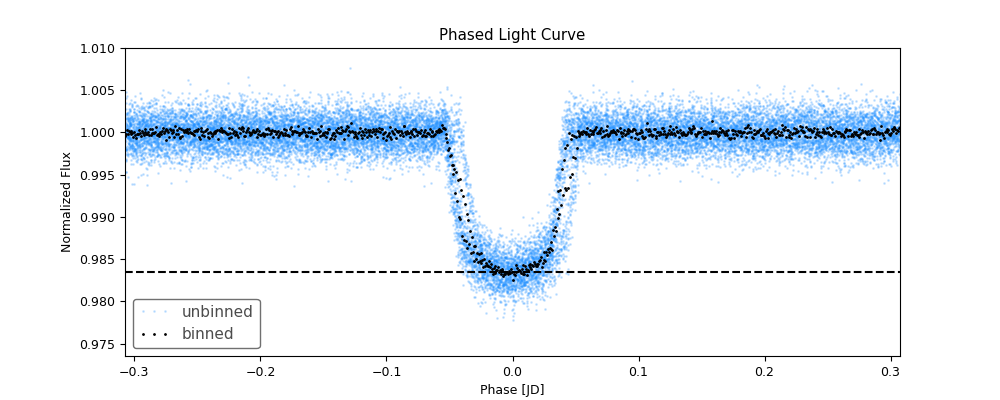

Exoplanet Index: 0
12.6907 earthRad
1.1322 jupiterRad


In [13]:
def clean_data(mission, refined_ts):
    transit_mask = refined_ts.create_transit_mask(
                period = periods, 
                transit_time = transit_times, 
                duration = durations
            )
    if len(mission) > 1:
        clean_ts = raw_ts.stitch().remove_nans().flatten(mask = transit_mask)
    else:
        clean_ts = first_ts.remove_nans().flatten(mask = transit_mask)
    return clean_ts

def plot_light_curve(clean_ts, period, t0, duration):
    phased_lc = clean_ts.fold(period = period, epoch_time = t0)
    binned_lc = phased_lc.bin(1/60/24)
    dip = np.mean(binned_lc[np.logical_and(binned_lc.time > -duration*.1, binned_lc.time < duration*.1)].flux.value)
    depth = 1-dip
    half_duration = duration.value/2
    if render_plots == True:
        fig, ax = plt.subplots(figsize = (10,4))
        phased_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "dodgerblue", alpha = .2, label = "unbinned")
        binned_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "black", label = "binned")
        plt.axhline(dip, color = 'black', linestyle = '--')
        plt.title("Phased Light Curve")
        plt.xlim(-(half_duration + .25), (half_duration + .25))
        plt.ylim(dip - .01, 1.01)
        plt.show()
    return depth, binned_lc, phased_lc

def estimate_radius(star, depth):
    exo_sun_rad = np.sqrt(depth) * (star["rad"][0] * u.R_sun)
    exo_earth_rad = exo_sun_rad.to(u.Rearth) 
    exo_jupiter_rad = exo_sun_rad.to(u.Rjupiter) 
    print(round(exo_earth_rad, 4))
    print(round(exo_jupiter_rad, 4))
    return exo_earth_rad

def run_lc_loop(exoplanets, clean_ts):
    for each in exoplanets:
        depth, binned_lc, phased_lc = plot_light_curve(clean_ts, each["period"], each["transit_t0"], each["duration"])
        each["depth"] = depth*1000*u.mmag
    
        transit_event = np.logical_and(binned_lc.phase.value > -0.2, binned_lc.phase.value < 0.2)
        each["light_curve"] = binned_lc[transit_event]

        print(f'Exoplanet Index: {exoplanets.index(each)}')
        radius = estimate_radius(star, depth)
        each["radius"] = radius

if remove_lc == False:
    if telescope == "TIC":
        clean_ts = clean_data(sectors, refined_ts)
    if telescope == "KIC":
        clean_ts = clean_data(quarters, refined_ts)
        
    run_lc_loop(exoplanets, clean_ts)
    remove_lc = True
else:
    remove_index = int(input('Remove Candidate(s)?'))
    del exoplanets[remove_index]
    run_lc_loop(exoplanets, clean_ts)

Exoplanet Index: 0
Radius: 12.1126 earthRad
Inclination: 86.0252 deg
Eccentricity: 0.2145
Argument of Periapsis (ω): 0.0 deg


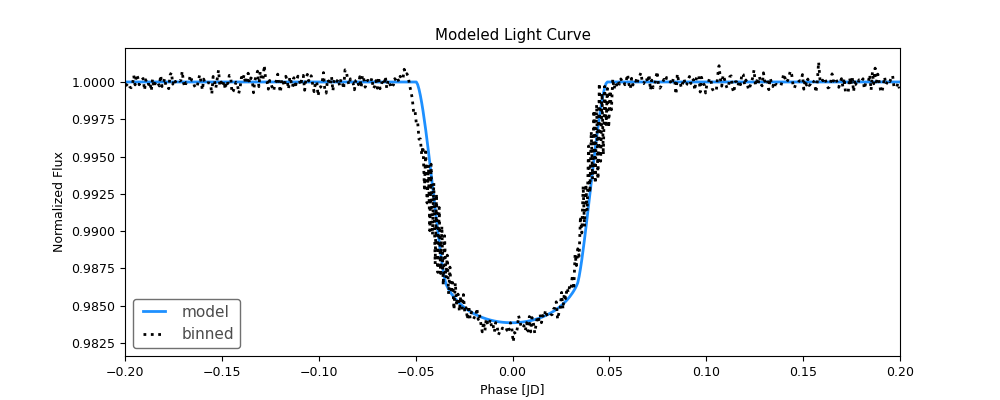

In [14]:
def initial_estimates(exoplanet, star):
    rad_est = (exoplanet['radius'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    inc_est = 90
    ecc_est = 0
    w_est = 90
    estimates = [rad_est, inc_est, ecc_est, w_est]
    lower_bounds = [rad_est-0.02,80,0,0]
    upper_bounds = [rad_est+0.02,90,0.999,180]
    return estimates, lower_bounds, upper_bounds
    
def batman_fun(x, exoplanet, star):
    params = batman.TransitParams()
    params.t0 = 0
    params.per = exoplanet['period'].value
    params.rp = x[0]
    params.a = (exoplanet['sm_axis'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    params.inc = x[1]
    params.ecc = x[2]
    params.w = x[3]
    params.limb_dark = 'nonlinear'
    params.u = [0.5,0.1,0.1,-0.1]  
    
    phase_min = min(exoplanet['light_curve'].phase.value)
    phase_max = max(exoplanet['light_curve'].phase.value)
    phase_len = len(exoplanet['light_curve'].flux.value)
    time = np.linspace(phase_min, phase_max, phase_len)
                       
    model = batman.TransitModel(params,time)
    batman_flux = model.light_curve(params)
    return batman_flux

def calc_residuals(x, exoplanet, star):
    observed = exoplanet['light_curve'].flux.value
    observed_error = exoplanet['light_curve'].flux_err.value
    modeled = batman_fun(x, exoplanet, star)
    
    residuals = (observed-modeled)/observed_error
    return residuals

def plot_model(each, star):
    batman_flux = batman_fun(results.x, each, star)
    phase = each['light_curve'].phase.value

    fig, ax = plt.subplots(figsize = (10,4))
    ax.plot(phase, batman_flux, linewidth = '2', color = 'dodgerblue', label = 'model')
    each['light_curve'].plot(ax = ax, linewidth = '2', linestyle = ':', color = 'black', label = 'binned')
    plt.title('Modeled Light Curve')
    plt.xlim(-0.2,0.2)
    plt.show()

for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    estimates, lower_bounds, upper_bounds = initial_estimates(each, star)
    results = optimize.least_squares(calc_residuals, estimates, bounds = (lower_bounds, upper_bounds), args = (each, star,))

    each['radius'] = (results.x[0]*star['rad'][0]*u.Rsun).to(u.Rearth)
    each['inclination'] = results.x[1]*u.degree
    each['eccentricity'] = results.x[2]
    each['arg_periapsis'] = results.x[3]*u.degree
    print(f'Radius: {round(each['radius'],4)}')
    print(f'Inclination: {round(each['inclination'],4)}')
    print(f'Eccentricity: {round(each['eccentricity'],4)}')
    print(f'Argument of Periapsis (ω): {round(each['arg_periapsis'],4)}')

    plot_model(each, star)
    each.pop('light_curve')

In [15]:
for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    b1 = ((each['sm_axis']*np.cos(each['inclination'].to(u.radian)))/((star['rad'][0]*u.Rsun).to(u.au)))
    b2 = ((1-np.square(each['eccentricity']))/(1+(np.square(each['eccentricity'])*np.sin(each['arg_periapsis'].to(u.radian)))))

    each['impact_parameter'] = b1*b2
    print(f'Impact Parameter: {round(each['impact_parameter'],4)}')
    print()

Exoplanet Index: 0
Impact Parameter: 0.5682



### Radial Velocity Method

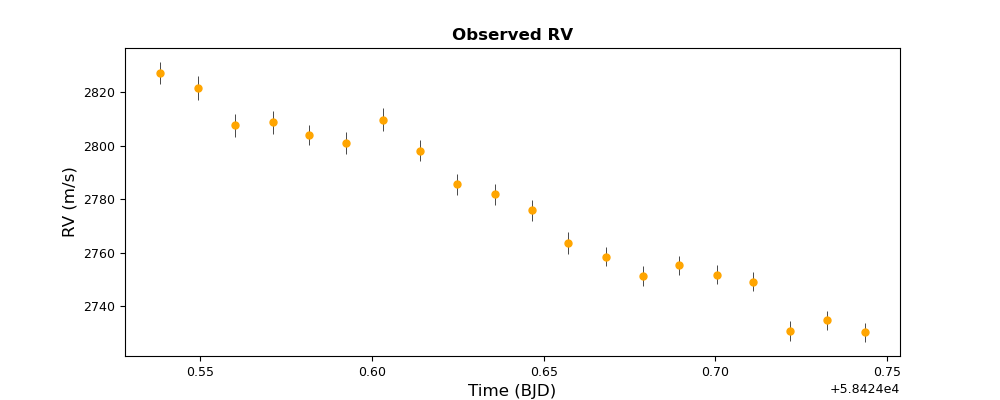

In [16]:
if RV == True:
    def plot_rv(rv_time, rv, rv_err):
        fig, ax = plt.subplots(figsize = (10,4))
        ax.errorbar(rv_time, rv, rv_err, fmt= 'o', color = 'orange', ecolor = 'black', elinewidth = .5)
        ax.set_xlabel('Time (BJD)', fontsize = 12)
        ax.set_ylabel('RV (m/s)', fontsize = 12)
    
    def import_harps():
        rv_ts = Spectroscopy.get_timeseries(input_catalog, sorted_by_instrument = True)
            
        index = []
        for each in rv_ts.keys():
            if each.find('HARPS15') != -1:
                index.append(each)
            elif each.find('HARPS') != -1:
                index.append(each)
        index0 = index[0]
        index1 = list(rv_ts[index0])[0]
        index2 = list(rv_ts[index0][index1])[0]
        rv_data = rv_ts[index0][index1][index2]
        rv_time, rv, rv_err = rv_data['rjd'], rv_data['rv'], rv_data['rv_err'] 
    
        if render_plots == True:
            plot_rv(rv_time, rv, rv_err)
            plt.title('Observed RV', fontsize = 12, fontweight = 'bold')
        
        rv_norm = (rv - np.median(rv))    
        sigma2 = 2*np.std(rv_norm)    
        
        i = 0 
        while i < len(rv_norm):
            if (rv_norm[i] > sigma2) or (rv_norm[i] < -sigma2):
                rv_time = np.delete(rv_time, i)
                rv = np.delete(rv, i)
                rv_err = np.delete(rv_err, i)
            i += 1
        return input_catalog, rv_time, rv, rv_err
    
    input_catalog, rv_time, rv, rv_err = import_harps()

parameter                     value      vary
per1                        2.79862      False
tc1                         3129.67       True
secosw1                           0      False
sesinw1                           0      False
logk1                       5.37683       True
dvdt                       -2.88524       True
curv                      -0.295596       True
gamma                       2746.54      False
jit                          3.7704       True
tp1                         3128.97           
e1                                0           
w1                                0           
k1                          216.335           

Priors
------



ERFA function "d2dtf" yielded 2 of "dubious year (Note 5)"
ERFA function "dtf2d" yielded 2 of "dubious year (Note 6)"


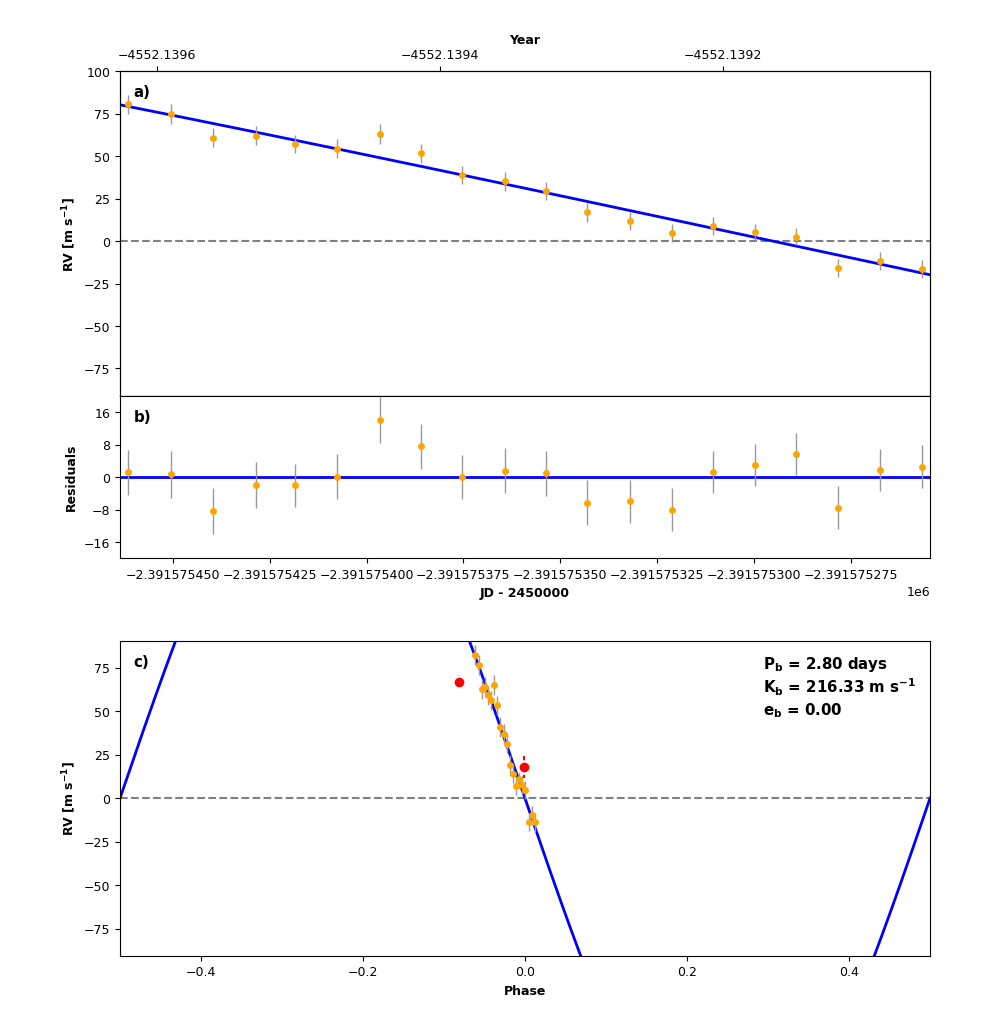

In [17]:
if RV == True:
    def initialize_model():
        time_base = int(np.mean(rv_time))
        params = radvel.Parameters(len(exoplanets), basis = 'per tc secosw sesinw logk')
        i = 0
        while i < len(exoplanets):
            params[f'per{i+1}'] = radvel.Parameter(value = exoplanets[i]['period'].value)
            params[f'tc{i+1}'] = radvel.Parameter(value = exoplanets[i]['transit_t0'].value)
            params[f'secosw{i+1}'] = radvel.Parameter(value = 0)    #np.sqrt(exoplanets[i]['eccentricity'])*np.cos(exoplanets[i]['arg_periapsis'].to(u.rad).value)) 
            params[f'sesinw{i+1}'] = radvel.Parameter(value = 0)    #np.sqrt(exoplanets[i]['eccentricity'])*np.sin(exoplanets[i]['arg_periapsis'].to(u.rad).value)) 
            params[f'logk{i+1}'] = radvel.Parameter(value = np.log(np.std(rv)))
            i += 1
        radvel_model = radvel.RVModel(params, time_base = time_base)
        radvel_model.params['dvdt'] = radvel.Parameter(value = 0)
        radvel_model.params['curv'] = radvel.Parameter(value = 0)
        
        like = radvel.likelihood.RVLikelihood(radvel_model, rv_time, rv, rv_err)
        like.params['gamma'] = radvel.Parameter(value = np.median(rv), vary = False, linear = True)
        like.params['jit'] = radvel.Parameter(value = 1)
        i = 0
        while i < len(exoplanets):
            like.params[f'per{i+1}'].vary = False
            like.params[f'tc{i+1}'].vary = True
            like.params[f'secosw{i+1}'].vary = False
            like.params[f'sesinw{i+1}'].vary = False
            like.params[f'logk{i+1}'].vary = True
            i += 1
        return radvel_model, like

    def run_rvmodel():
        posterior = radvel.posterior.Posterior(like)
        results = optimize.minimize(posterior.neglogprob_array, posterior.get_vary_params(), method = 'Powell')
        derived_params = like.params.basis.to_synth(like.params)
        print(posterior)
        orbit_plots.MultipanelPlot(posterior, legend = False, figwidth = 10).plot_multipanel()
        
    radvel_model, like = initialize_model()
    run_rvmodel()
    i = 0
    derived_params = like.params.basis.to_synth(like.params)
    while i < len(exoplanets):
        exoplanets[i]['semiamplitude']= derived_params[f'k{i+1}'].value*u.m/u.s
        i += 1

In [18]:
if RV == True:    
    def calc_mass(k, period, inclination, eccentricity):
        m1 = (period*u.day.to(u.s)*u.s)/(2*np.pi*const.G)
        m2 = k
        m3 = star['mass'][0]*u.M_sun.to(u.kg)*u.kg
        m4 = 1    #-(eccentricity**2)
        d1 = np.sin(np.deg2rad(inclination))
        mass = ((m1**(1/3)) * m2 * (m3**(2/3)) * (m4**(1/2)))/d1
        mass_E = mass.to(u.Mearth)
        mass_J = mass.to(u.Mjupiter)
    
        if mass_E < 2*u.Mearth:
            exo_class = 'Terrestrial'
        elif mass_E < 10*u.Mearth:
            exo_class = 'Super-Earth'
        elif mass_E < 15*u.Mearth:
            exo_class = 'Sub-Neptune'
        elif mass_E < 150*u.Mearth:
            exo_class = 'Neptunian'
        elif mass_J < 13*u.Mjupiter:
            exo_class = 'Jovian'
        else:
            exo_class = 'Brown Dwarf'
        
        print(f'Mass: {round(mass_E, 4)}')
        print(f'Mass: {round(mass_J, 4)}')
        print(f'Class: {exo_class}')
        return mass_E, mass_J, exo_class
    
    for each in exoplanets:
        print(f'Exoplanet Index: {exoplanets.index(each)}')
        mass_E, mass_J, exo_class = calc_mass(each['semiamplitude'], each['period'].value, each['inclination'].value, each['eccentricity'])
        each['mass_E'], each['mass_J'], each['exo_class'] = mass_E, mass_J, exo_class
        print()

Exoplanet Index: 0
Mass: 415.264 earthMass
Mass: 1.3066 jupiterMass
Class: Jovian



In [19]:
if RV == True:
    def calc_bulk_density(mass, radius):
        volume = (4/3)*np.pi*((radius.to(u.cm))**3)
        mass_g = mass.to(u.g)
        bulk_density = mass_g/volume
        if bulk_density.value < 2.1:    
            composition = 'Ice/Gas' 
        elif bulk_density.value < 3.6:    
            composition = 'Rock/Ice'
        elif bulk_density.value < 13.4:    
            composition = 'Iron/Rock'
        elif bulk_density.value > 25:    
            composition = 'Iron'
        else:   
            composition = 'Degenerate'
            
        print(f'Bulk Density: {round(bulk_density, 4)}')
        print(f'Composition: {composition}')
        return bulk_density, composition
    
    def calc_surf_grav(mass, radius):
        mass_kg = mass.to(u.kg)
        radius_m = radius.to(u.m)
        surf_grav = (const.G*mass_kg)/(radius_m**2)
        print(f'Surface Gravity: {round(surf_grav, 4)}')
        return surf_grav
    
    for each in exoplanets:
        print(f'Exoplanet Index: {exoplanets.index(each)}')
        bulk_density, composition = calc_bulk_density(each['mass_E'], each['radius'])
        each['bulk_density'] = bulk_density
        each['composition'] = composition
        
        surf_grav = calc_surf_grav(each['mass_E'], each['radius'])
        each['surf_grav'] = surf_grav
        print()

Exoplanet Index: 0
Bulk Density: 1.2841 g / cm3
Composition: Ice/Gas
Surface Gravity: 27.7336 m / s2



### Results & Comparison

In [20]:
for each in exoplanets:
    match = nasa_exo[round(nasa_exo['pl_orbper']) == round(each['period'])]
    radius_accuracy = round((1-np.abs(match['pl_rade']-each['radius'])/match['pl_rade'])*100, 2)
    each['rad_acc'] = str(f'{radius_accuracy.iloc[0]}%')
    mass_accuracy = round((1-np.abs(match['pl_bmasse']-each['mass_E'])/match['pl_bmasse'])*100, 2)
    each['mass_acc'] = str(f'{mass_accuracy.iloc[0]}%')
    each['date'] = datetime.datetime.now().strftime('%x')

exo_rounded = deepcopy(exoplanets)
for exo in exo_rounded:
    for each in exo:
        try:
            if type(exo[each]) != str:
                exo[each] = round(exo[each], 2)
        except:
            exo[each] = round(float(exo[each].value), 2)
pd.DataFrame(exo_rounded).transpose()

,0
catalog,TIC 238176110
stellar_class,K-Type Orange Dwarf
period,2.8 d
duration,0.12 d
transit_t0,3128.97
depth,16.47 mmag
snr,356.54
sm_axis,0.04 AU
equ_temp,1190.55 k
habitability,too hot


In [21]:
export_results = False

In [22]:
results_filepath = '/Users/joshu/Code/Exoplanet_Pipeline_Output.csv'
saved_results = pd.read_csv(results_filepath)

if export_results == True:
    export_filepath = '/Users/joshu/Code/Exoplanet_Pipeline_Output.csv'
    pd.DataFrame(exoplanets).to_csv(results_filepath, mode = 'a', header = False)
export_results = True

saved_results

,index,catalog,stellar_class,period,duration,transit_t0,depth,snr,sm_axis,equ_temp,...,semiamplitude,mass_E,mass_J,exo_class,bulk_density,composition,surf_grav,rad_acc,mass_acc,date
0,0,TIC 307210830,M-Type Red Dwarf,3.6906769884537267 d,0.04419999999999999 d,2256.725905,1.5551479320516925 mmag,58.905030,0.03103701137296962 AU,526.061209806214 k,...,2.2051241136683797 m / s,2.350696585440267 earthMass,0.007396118586838905 jupiterMass,Super-Earth,5.911474083914761 g / cm3,Iron/Rock,13.678490847502013 m / s2,97.64%,82.47%,9/8/2026
1,1,TIC 307210830,M-Type Red Dwarf,7.450709222553008 d,0.03 d,2256.830005,1.6705525481205408 mmag,32.212325,0.049576319319610415 AU,416.235470463014 k,...,1.2488914637924473 m / s,1.6827560764250264 earthMass,0.0052945427202516805 jupiterMass,Terrestrial,2.7022877700455217 g / cm3,Rock/Ice,7.261119512999155 m / s2,92.62%,97.39%,9/8/2026
2,2,TIC 307210830,M-Type Red Dwarf,2.2530943531549577 d,0.03 d,2256.161005,0.5039482663597994 mmag,21.979883,0.022335488571885595 AU,620.123941418039 k,...,0.37893017308630617 m / s,0.34289218027400054 earthMass,0.0010788594510725703 jupiterMass,Terrestrial,4.43036637222367 g / cm3,Iron/Rock,5.940929796464398 m / s2,89.85%,74.54%,9/8/2026
3,0,TIC 266980320,G-Type Yellow Dwarf,6.034569487017465 d,0.07370000000000002 d,3887.814415,1.4693722722670666 mmag,20.273005,0.06421293021706707 AU,1078.5823908909529 k,...,6.2766605684309935 m / s,17.547280831540093 earthMass,0.05520991977887636 jupiterMass,Neptunian,1.1147652617440889 g / cm3,Ice/Gas,8.790920626180858 m / s2,90.29%,99.70%,9/8/2026
4,0,TIC 19028197,M-Type Red Dwarf,3.3366607481149893 d,0.066 d,2500.535179,6.284036149541872 mmag,113.486456,0.0346323165495819 AU,650.6078354986113 k,...,8.99979606443297 m / s,13.209172953881543 earthMass,0.04156070596523849 jupiterMass,Sub-Neptune,1.1153604156810455 g / cm3,Ice/Gas,7.999769844661306 m / s2,88.02%,95.03%,9/8/2026
5,0,TIC 238176110,K-Type Orange Dwarf,2.7986153772981814 d,0.11499999999999999 d,3128.967677,16.46749241769241 mmag,356.535112,0.03622915452291924 AU,1190.5498523881774 k,...,216.33459028929963 m / s,415.263964749072 earthMass,1.30656655016572 jupiterMass,Jovian,1.2840570106770062 g / cm3,Ice/Gas,27.733610909286945 m / s2,95.09%,97.50%,9/8/2026
6,0,TIC 429302040,K-Type Orange Dwarf,5.722339765652701 d,0.0935 d,3776.916371,24.336882970470207 mmag,192.291438,0.054512753710243216 AU,744.7347280396407 k,...,13.686176755021178 m / s,29.030883624610187 earthMass,0.091341374849584 jupiterMass,Neptunian,0.10481721967737702 g / cm3,Ice/Gas,2.1498952859087166 m / s2,90.83%,95.15%,9/8/2026
7,0,TIC 190496853,A-Type White Dwarf,4.661620827208176 d,0.15399999999999997 d,2259.492392,10.1594931156902 mmag,230.054308,0.06517914403371312 AU,1833.6078125835113 k,...,47.96177722211289 m / s,178.8280186255968 earthMass,0.5626558700074138 jupiterMass,Jovian,0.16752413685009931 g / cm3,Ice/Gas,5.387313467429818 m / s2,95.04%,70.65%,9/8/2026
8,0,TIC 259377017,M-Type Red Dwarf,5.6605672585250595 d,0.05499999999999999 d,1389.499827,3.386831168951665 mmag,37.832353,0.044311869605686054 AU,495.0368343911572 k,...,3.2303457083203697 m / s,4.575918958793663 earthMass,0.014397451152405372 jupiterMass,Super-Earth,2.249525048363021 g / cm3,Rock/Ice,8.96868551278227 m / s2,95.96%,73.81%,9/8/2026
9,1,TIC 259377017,M-Type Red Dwarf,11.379591291513046 d,0.07370000000000002 d,1389.679277,2.387929650592424 mmag,12.934622,0.07058263708902532 AU,392.2370480429239 k,...,1.9536911350547683 m / s,3.4924129359380753 earthMass,0.010988359956106551 jupiterMass,Super-Earth,2.541718219647846 g / cm3,Rock/Ice,8.891375044334454 m / s2,98.09%,83.15%,9/8/2026


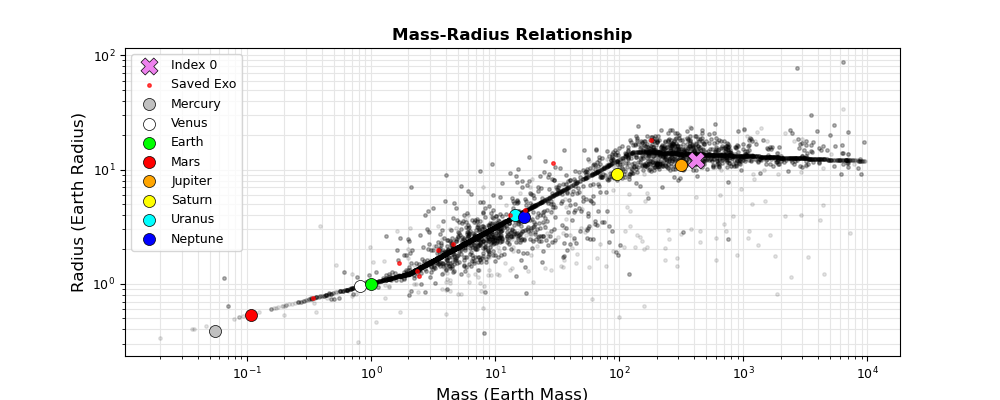

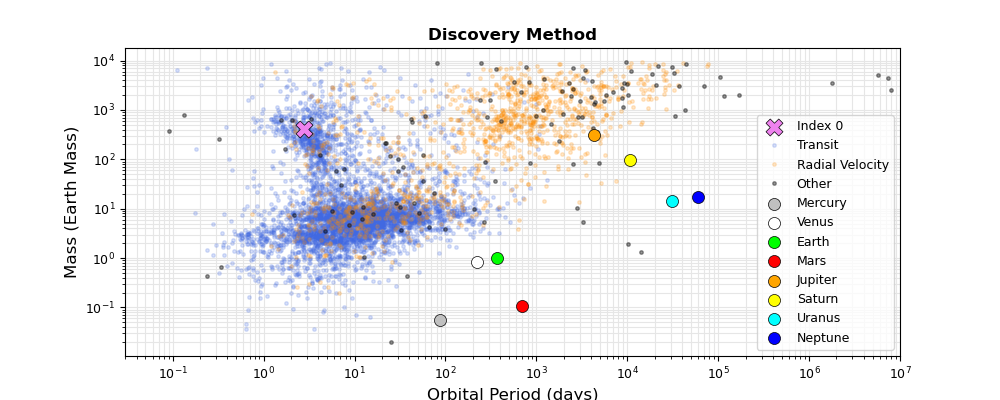

In [23]:
if RV == True and render_plots == True:
    def plot_mass_rad(exoplanet):
        fig, ax = plt.subplots(figsize = (10, 4))
        refined_constraints = np.logical_and(
            (nasa_archive['pl_radeerr1']/nasa_archive['pl_rade']) < 1,
            (nasa_archive['pl_bmasseerr1']/nasa_archive['pl_bmasse']) < 1
        )
        refined_archive = nasa_archive[refined_constraints]
        ax.loglog(nasa_archive['pl_bmasse'], nasa_archive['pl_rade'], '.', color = 'black', alpha = .1, zorder = 2)
        ax.loglog(refined_archive['pl_bmasse'], refined_archive['pl_rade'], '.', color = 'black', alpha = .2, zorder = 2)
        
        ax.grid(which = 'major', color = '.9', zorder = 1)
        ax.grid(which = 'minor', color = '.9', zorder = 1)
        ax.set_xlabel('Mass (Earth Mass)', fontsize = 12)
        ax.set_ylabel('Radius (Earth Radius)', fontsize = 12)
        ax.set_title('Mass-Radius Relationship', fontsize = 12, fontweight = 'bold')

        for each in exoplanets:
            if exoplanets.index(each) == 0:
                color = 'violet'
            if exoplanets.index(each) == 1:
                color = 'deepskyblue'
            if exoplanets.index(each) == 2:
                color = 'green'
            if exoplanets.index(each) == 3:
                color = 'gold'
            if exoplanets.index(each) == 4:
                color = 'salmon'
            
            ax.scatter(
                each['mass_E'].value, 
                each['radius'].value, 
                s = 150, 
                color = color, 
                marker = 'X', 
                edgecolor = 'black', 
                linewidth = .5, 
                label = (f'Index {exoplanets.index(each)}'), 
                zorder = 5
            )

        results_np = saved_results.to_numpy()
        i = 0
        while i < len(results_np):
            if i == 0:
                label = 'Saved Exo'
            else:
                label = None
            mass = float(results_np[i][17].split(' ')[0])
            radius = float(results_np[i][11].split(' ')[0])
            ax.scatter(mass, radius, s = 25, color = 'red', alpha = .7, marker = '.', zorder = 4, label = label)
            i += 1
        
        ax.scatter(0.0553, 0.383, s = 300, marker = '.', color = 'silver', label = 'Mercury', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(0.815, 0.95, s = 300, marker = '.', color = 'white', label = 'Venus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(1, 1, s = 300, marker = '.', color = 'lime', label = 'Earth', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(0.107, 0.53, s = 300, marker = '.', color = 'red', label = 'Mars', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(317.8, 10.97, s = 300, marker = '.', color = 'orange', label = 'Jupiter', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(95.2, 9.14, s = 300, marker = '.', color = 'yellow', label = 'Saturn', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(14.5, 3.98, s = 300, marker = '.', color = 'cyan', label = 'Uranus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(17.1, 3.86, s = 300, marker = '.', color = 'blue', label = 'Neptune', edgecolor = 'black', linewidths = .5, zorder = 3)
        plt.legend()

    def plot_disc_meth(exoplanet):
        fig, ax = plt.subplots(figsize = (10, 4))

        for each in exoplanets:
            if exoplanets.index(each) == 0:
                color = 'violet'
            if exoplanets.index(each) == 1:
                color = 'deepskyblue'
            if exoplanets.index(each) == 2:
                color = 'green'
            if exoplanets.index(each) == 3:
                color = 'gold'
            if exoplanets.index(each) == 4:
                color = 'salmon'
            
            ax.scatter(
                each['period'].value, 
                each['mass_E'].value, 
                s = 150, 
                color = color, 
                marker = 'X', 
                edgecolor = 'black', 
                linewidth = .5, 
                label = (f'Index {exoplanets.index(each)}'), 
                zorder = 4
            )

        disc_tran = nasa_archive[nasa_archive['discoverymethod'] == 'Transit']
        ax.loglog(disc_tran['pl_orbper'], disc_tran['pl_bmasse'], '.', color = 'royalblue', alpha = .2, label = 'Transit', zorder = 2)
        disc_rv = nasa_archive[nasa_archive['discoverymethod'] == 'Radial Velocity']
        ax.loglog(disc_rv['pl_orbper'], disc_rv['pl_bmasse'], '.', color = 'darkorange', alpha = .2, label = 'Radial Velocity', zorder = 2)
        disc_other = nasa_archive[np.logical_and(nasa_archive['discoverymethod'] != 'Transit', nasa_archive['discoverymethod'] != 'Radial Velocity')]
        ax.loglog(disc_other['pl_orbper'], disc_other['pl_bmasse'], '.', color = 'black', label = 'Other', alpha = .4, zorder = 2)
        
        ax.grid(which = 'major', color = '.9', zorder = 1)
        ax.grid(which = 'minor', color = '.9', zorder = 1)
        ax.set_xlabel('Orbital Period (days)', fontsize = 12)
        ax.set_ylabel('Mass (Earth Mass)', fontsize = 12)
        ax.set_title('Discovery Method', fontsize = 12, fontweight = 'bold')
        plt.xlim(right = 10**7)
        
        ax.scatter(87.97, 0.0553, s = 300, marker = '.', color = 'silver', label = 'Mercury', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(224.70, 0.815, s = 300, marker = '.', color = 'white', label = 'Venus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(365.26, 1, s = 300, marker = '.', color = 'lime', label = 'Earth', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(686.98, 0.107, s = 300, marker = '.', color = 'red', label = 'Mars', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(4332.82, 317.8, s = 300, marker = '.', color = 'orange', label = 'Jupiter', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(10755.70, 95.2, s = 300, marker = '.', color = 'yellow', label = 'Saturn', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(30687.15, 14.5, s = 300, marker = '.', color = 'cyan', label = 'Uranus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(60190.03, 17.1, s = 300, marker = '.', color = 'blue', label = 'Neptune', edgecolor = 'black', linewidths = .5, zorder = 3)
        plt.legend()

    plot_mass_rad(exoplanets)
    plot_disc_meth(exoplanets)

#### Ideas for improvement
- merge transit & rv model
- add uncertainty margins (markov chain monte carlo)
- import archive API instead of downloaded file
- test false positives
- imporove detection for longer periods
- transit timing variations
- atmospheric spectroscopy
- demonstrate doppler shift
- astrometry method